# Two crucial figures: prediction quality and adversarial robustness

This notebook implements the two agreed paper figures. It separates **measured**, **unverified**, and **missing** results; performs byte/token round-trip checks where possible; and never replaces a missing serialized size with an entropy estimate. The oracle in Figure 1 is an entropy-only reference, not an operational codec.

Figure 1 uses only non-overlapping text8 blocks. Qwen and Anti-Qwen use identical token sequences and the same integer-frequency arithmetic coder. Anti-Qwen is defined precisely as $\operatorname{softmax}(-z_{\rm Qwen})$. Figure 2 counts complete streams for token IDs, FSST, and Brotli. Qwen model weights and the global Qwen token table are treated as shared decoder state.

In [1]:
from pathlib import Path
import json, math, os, random, sys

START = Path.cwd().resolve()
ROOT = next(candidate for candidate in (START, *START.parents) if (candidate / 'pyproject.toml').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

from evaluation.crucial_figures import (
    benchmark_brotli, benchmark_fsst, benchmark_tokenization,
    find_repo_root, parse_predictive_payload, plot_compressor_bars,
    plot_surprisal_scatter, read_json, serialize_predictive_payload,
    validate_bar_results,
)
from src.encoding import LLMCompressor, LLMDecompressor
from src.qwen_stream import parse_qwen_stream, verify_decoded_bytes

assert find_repo_root() == ROOT
FIGURE_DIR = ROOT / 'artifacts/figures/neurips/crucial'
RESULT_DIR = ROOT / 'artifacts/runs/crucial-figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'Qwen/Qwen2.5-0.5B'
TEXT8 = ROOT / 'data/text8'
FSST_COMMIT = 'e638d4cf8c26129d73c242a4127b42b975de5b63'
FSST_EXECUTABLE = Path(os.environ.get('FSST_EXECUTABLE', '/tmp/compression-economics-fsst/build/fsst'))

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 8.5,
    'axes.titlesize': 9.5, 'axes.titleweight': 'bold',
    'axes.labelsize': 8.5, 'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5, 'legend.fontsize': 7.2,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.03,
})

def save_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    fig.savefig(png, dpi=300)
    print("Saved", png.relative_to(ROOT))

assert TEXT8.is_file() and TEXT8.stat().st_size == 100_000_000
print('Repository:', ROOT)
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('FSST:', FSST_EXECUTABLE if FSST_EXECUTABLE.is_file() else 'not configured')

Repository: /home/neubauer/src/compression-economics
Torch: 2.10.0+cu128 | CUDA: False
FSST: /tmp/compression-economics-fsst/build/fsst


## Figure 1 — prediction quality versus realized compression on text8

The unit of observation is an independently coded, non-overlapping 64-token text8 block. The x-axis is the unquantized model NLL in bits per predicted token. The y-axis is the byte length of a concrete predictive stream divided by the block's decoded UTF-8 bytes. Its 28-byte header records format/model code, seed token, token count, raw byte count, and arithmetic payload length; model weights remain shared.

The arithmetic decoder is checked against every encoded token. Because the current frequency table reserves one count for every vocabulary item, very small Anti-Qwen probabilities may be clipped to a much shorter code than their model NLL suggests.

In [2]:
SCATTER_CACHE = RESULT_DIR / 'text8_model_scatter.csv'
N_BLOCKS = 12
TOKENS_PER_BLOCK = 64
RUN_FRESH_MODEL_SCORING = not SCATTER_CACHE.exists()

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, cache_dir=ROOT / '.cache', local_files_only=True
)
vocab_size = tokenizer.vocab_size
assert vocab_size == 151_643

def text8_token_prefix(limit):
    text = ''
    chunk_size = max(65_536, limit * 8)
    with TEXT8.open('r', encoding='utf-8', newline='') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                raise ValueError(f'text8 contains fewer than {limit} tokens')
            text += chunk
            tokens = tokenizer.encode(text, add_special_tokens=False)
            if len(tokens) >= limit:
                return tokens[:limit]

def score_distribution(logits, targets, sign, model_code, raw, seed):
    compressor = LLMCompressor()
    surprisal = 0.0
    for row, target in zip(logits, targets):
        signed = sign * row.double()
        surprisal += float((torch.logsumexp(signed, 0) - signed[target]) / math.log(2))
        probabilities = torch.softmax(signed, 0).numpy()
        compressor.next_token(int(target), probabilities)
    bits = compressor.compress()
    stream = serialize_predictive_payload(
        bits, seed_token=int(seed), model_code=model_code,
        token_count=len(targets) + 1, raw_size_bytes=len(raw),
    )
    parsed = parse_predictive_payload(stream)
    decoder = LLMDecompressor(parsed['bits'])
    reconstructed = [int(seed)]
    for row in logits:
        probabilities = torch.softmax(sign * row.double(), 0).numpy()
        reconstructed.append(decoder.decompress(probabilities))
    assert reconstructed == [int(seed), *map(int, targets)]
    return {
        'surprisal_bits_per_token': surprisal / len(targets),
        'arithmetic_payload_bits': len(bits),
        'serialized_size_bytes': len(stream),
        'raw_size_bytes': len(raw),
        'relative_size_percent': 100 * len(stream) / len(raw),
        'round_trip': True,
    }

if RUN_FRESH_MODEL_SCORING:
    all_tokens = text8_token_prefix(N_BLOCKS * TOKENS_PER_BLOCK)
    assert len(all_tokens) == N_BLOCKS * TOKENS_PER_BLOCK
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, cache_dir=ROOT / '.cache', local_files_only=True, torch_dtype='auto'
    ).eval()
    rows = []
    with torch.inference_mode():
        for block_index in range(N_BLOCKS):
            block = all_tokens[block_index*TOKENS_PER_BLOCK:(block_index+1)*TOKENS_PER_BLOCK]
            raw = tokenizer.decode(
                block, skip_special_tokens=False, clean_up_tokenization_spaces=False
            ).encode('utf-8')
            assert tokenizer.encode(raw.decode('utf-8'), add_special_tokens=False) == block
            input_ids = torch.tensor([block])
            logits = model(input_ids=input_ids, use_cache=False).logits[0, :-1, :vocab_size].cpu()
            targets = block[1:]
            for name, sign, code in [('Qwen2.5-0.5B', 1, 1), ('Anti-Qwen', -1, 2)]:
                result = score_distribution(logits, targets, sign, code, raw, block[0])
                rows.append({'block': block_index, 'model': name, **result})
            print(f'Finished block {block_index + 1}/{N_BLOCKS}')
    scatter = pd.DataFrame(rows)
    scatter.to_csv(SCATTER_CACHE, index=False)
    del model
else:
    scatter = pd.read_csv(SCATTER_CACHE)

assert len(scatter) == 2 * N_BLOCKS
assert scatter['round_trip'].all()
display(scatter.groupby('model').agg(
    blocks=('block', 'count'),
    surprisal_mean=('surprisal_bits_per_token', 'mean'),
    relative_size_mean=('relative_size_percent', 'mean'),
    relative_size_std=('relative_size_percent', 'std'),
).round(3))

,blocks,surprisal_mean,relative_size_mean,relative_size_std
model,,,,
Anti-Qwen,12,44.955,49.247,5.030
Qwen2.5-0.5B,12,6.120,24.570,2.819


Saved artifacts/figures/neurips/crucial/prediction_quality_vs_realized_compression.png


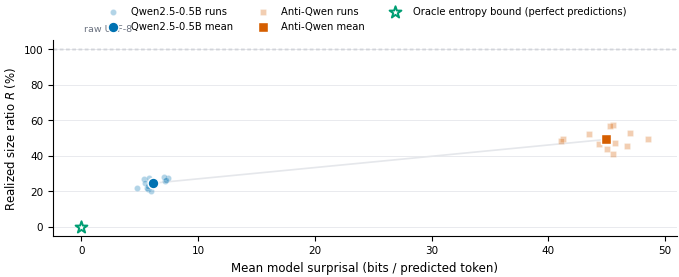

In [3]:
fig, ax = plot_surprisal_scatter(scatter)
save_figure(fig, 'prediction_quality_vs_realized_compression')
plt.show()

### Figure 1 interpretation

The translucent points are individual block runs; the larger solid markers are model means, and the line connects only those means. Qwen and Anti-Qwen change only the probability distribution. The oracle star at $(0,0)$ is the unattainable entropy limit and deliberately excludes framing. If Anti-Qwen's NLL grows much faster than its realized size, the cause is the arithmetic coder's finite-frequency floor—not unexpectedly good prediction.

## Figure 2 - End-to-end compression across natural and adversarial inputs

This section builds an audit table before plotting the completed 10k paper-evaluation artifacts. The baselines are the matched text8 prefix and seeded random printable UTF-8 control. The main comparison uses a full-vocabulary minimum-probability adversary and a one-byte UTF-8 ablation. The MaxSurprisal/Byte group uses the final 1,024-token evaluation; its Qwen bar reports a complete, decoder-verified QACS stream.

Qwen + AC bars use complete versioned streams containing the arithmetic payload, seed, model/coder configuration, framing, and any token dictionary. Every stream was independently decoded through Qwen back to identical token IDs and UTF-8 bytes. Qwen token IDs, FSST, and Brotli are likewise complete streams. Shared Qwen model weights and the shared tokenizer table are excluded for both Qwen representations.

The official FSST source is pinned to commit `e638d4cf8c26129d73c242a4127b42b975de5b63`. Set `FSST_EXECUTABLE` to its compiled `fsst` binary.

![Final baselines and adversaries](../../../artifacts/figures/neurips/crucial/end_to_end_compressor_robustness.png)


In [4]:
if 'tokenizer' not in globals():
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, cache_dir=ROOT / '.cache', local_files_only=True
    )
    vocab_size = tokenizer.vocab_size
    assert vocab_size == 151_643

DATASET_ORDER = [
    'text8', 'random text', 'MinProb adversary',
    'MaxSurprisal/Byte adversary', 'all one-byte adversary',
]
PLOT_DATASET_ORDER = DATASET_ORDER

def decoded_bytes(token_ids):
    return tokenizer.decode(
        token_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False
    ).encode('utf-8')

def load_attack_condition(output_dir, condition, run_index=0):
    payload = read_json(output_dir / 'results.json')
    matches = [
        row for row in payload['runs']
        if row['condition'] == condition and row['run_index'] == run_index
    ]
    if len(matches) != 1:
        raise ValueError(
            f'Expected one {condition} run {run_index} in {output_dir}, found {len(matches)}'
        )
    row = matches[0]
    stem = f"{condition}_run_{run_index:02d}"
    token_ids = read_json(output_dir / f'{stem}.tokens.json')
    data = (output_dir / f'{stem}.txt').read_bytes()
    assert token_ids == row['token_ids']
    assert decoded_bytes(token_ids) == data
    assert len(data) == row['decoded_utf8_size_bytes']
    return {
        'data': data,
        'token_ids': token_ids,
        'ac_payload_bits': row['arithmetic_payload_bits'],
        'provenance': str((output_dir / 'results.json').relative_to(ROOT)),
        'condition': condition,
        'run_index': run_index,
    }

sweep_root = ROOT / 'artifacts/runs/paper-evaluation'
printable_dir = sweep_root / 'printable-ascii_n10000'
random_dir = sweep_root / 'random_printable_n10000_tokens'
one_byte_dir = sweep_root / 'ascii-bytes_n10000'
random_payload = read_json(random_dir / 'results.json')
random_run = random_payload['runs'][0]
random_tokens = read_json(random_dir / 'random-text.tokens.json')
random_data = (random_dir / 'random-text.txt').read_bytes()
assert len(random_tokens) == random_payload['metadata']['requested_token_count'] == 10_000
assert random_tokens == random_run['token_ids']
assert decoded_bytes(random_tokens) == random_data
random_stream = (random_dir / 'random-text.qac').read_bytes()
random_parsed = parse_qwen_stream(random_stream)
verify_decoded_bytes(random_parsed, random_data)

datasets = {
    'text8': load_attack_condition(printable_dir, 'ordinary-text8'),
    'random text': {
        'data': random_data,
        'token_ids': random_tokens,
        'ac_payload_bits': random_run['arithmetic_payload_bits'],
        'qwen_serialized_size_bytes': len(random_stream),
        'qwen_round_trip': True,
        'provenance': str((random_dir / 'results.json').relative_to(ROOT)),
        'condition': 'random-printable-utf8',
        'run_index': 0,
    },
    'all one-byte adversary': load_attack_condition(
        one_byte_dir, 'surprisal-per-byte'
    ),
}

token_adv_dir = sweep_root / 'full_vocab_n10000'
full_payload = read_json(token_adv_dir / 'full' / 'results.json')
full_runs = [row for row in full_payload['runs'] if row['run_index'] == 0]
if len(full_runs) != 1:
    raise ValueError('Expected full-vocabulary run 0')
token_adv_row = full_runs[0]
token_adv_tokens = read_json(token_adv_dir / 'full' / 'run_00.tokens.json')
token_adv_data = (token_adv_dir / 'full' / 'run_00.txt').read_bytes()
assert token_adv_tokens == token_adv_row['token_ids']
assert decoded_bytes(token_adv_tokens) == token_adv_data
arithmetic = read_json(token_adv_dir / 'arithmetic_payloads.json')
full_ac = [
    row for row in arithmetic['runs']
    if row['policy'] == 'full' and row['run_index'] == 0
]
if len(full_ac) != 1:
    raise ValueError('Expected full-vocabulary arithmetic payload for run 0')
datasets['MinProb adversary'] = {
    'data': token_adv_data,
    'token_ids': token_adv_tokens,
    'ac_payload_bits': full_ac[0]['arithmetic_payload_bits'],
    'provenance': str((token_adv_dir / 'arithmetic_payloads.json').relative_to(ROOT)),
    'condition': 'min-probability',
    'run_index': 0,
}

maxspb_dir = ROOT / "artifacts/runs/smoke-surprisal-per-byte-n1024"
datasets["MaxSurprisal/Byte adversary"] = load_attack_condition(
    maxspb_dir, "surprisal-per-byte"
)

finalized_dir = sweep_root / 'finalized-qwen-bars-b10000'
finalized_payload = read_json(finalized_dir / 'results.json')
assert finalized_payload['metadata']['model_name'] == MODEL_NAME
finalized_runs = {('MinProb adversary' if row['dataset'] == 'token-level adversary' else row['dataset']): row for row in finalized_payload['runs']}
assert set(DATASET_ORDER) - {'random text', 'MaxSurprisal/Byte adversary'} <= set(finalized_runs)
for dataset, run in {name: finalized_runs[name] for name in DATASET_ORDER if name in finalized_runs and name != 'random text'}.items():
    stream_path = ROOT / run['stream']
    stream = stream_path.read_bytes()
    parsed_stream = parse_qwen_stream(stream)
    token_ids = read_json(ROOT / run['tokens'])
    data = (ROOT / run['decoded_text']).read_bytes()
    assert parsed_stream['token_count'] == len(token_ids) == run['token_count']
    assert len(data) == run['raw_size_bytes']
    assert len(stream) == run['serialized_size_bytes']
    assert run['token_round_trip'] and run['byte_round_trip']
    verify_decoded_bytes(parsed_stream, data)
    datasets[dataset] = {
        'data': data,
        'token_ids': token_ids,
        'ac_payload_bits': run['payload_bits'],
        'qwen_serialized_size_bytes': len(stream),
        'qwen_round_trip': True,
        'provenance': run['stream'],
        'condition': datasets[dataset]['condition'],
        'run_index': datasets[dataset]['run_index'],
    }

display(pd.DataFrame([
    {
        'dataset': name,
        'raw_size_bytes': len(item['data']),
        'tokens': len(item['token_ids']),
        'ac_payload_bits': item['ac_payload_bits'],
        'condition': item['condition'],
        'provenance': item['provenance'],
    }
    for name, item in datasets.items()
]).set_index('dataset').loc[DATASET_ORDER].reset_index())


,dataset,raw_size_bytes,tokens,ac_payload_bits,condition,provenance
0,text8,10000,1825,11403,ordinary-text8,artifacts/runs/paper-evaluation/finalized-qwen...
1,random text,13087,10000,99256,random-printable-utf8,artifacts/runs/paper-evaluation/random_printab...
2,MinProb adversary,9996,1463,26303,min-probability,artifacts/runs/paper-evaluation/finalized-qwen...
3,MaxSurprisal/Byte adversary,1508,1024,14764,surprisal-per-byte,artifacts/runs/paper-evaluation/finalized-qwen...
4,all one-byte adversary,10000,10000,95585,surprisal-per-byte,artifacts/runs/paper-evaluation/finalized-qwen...


In [5]:
rows = []
for dataset in DATASET_ORDER:
    item = datasets[dataset]
    data, ids = item['data'], item['token_ids']
    token_result = benchmark_tokenization(
        data, ids, tokenizer=tokenizer, vocab_size=vocab_size
    )
    rows.append({
        'dataset': dataset, 'status': 'measured',
        'note': 'complete token-ID stream; shared Qwen token table excluded',
        **token_result,
    })
    brotli_result = benchmark_brotli(data, quality=11)
    rows.append({
        'dataset': dataset, 'status': 'measured',
        'note': 'complete Brotli stream', **brotli_result,
    })
    if FSST_EXECUTABLE.is_file():
        fsst_result = benchmark_fsst(data, executable=FSST_EXECUTABLE)
        rows.append({
            'dataset': dataset, 'status': 'measured',
            'note': f'official FSST CLI at {FSST_COMMIT}', **fsst_result,
        })
    else:
        rows.append({
            'dataset': dataset, 'codec': 'FSST', 'status': 'missing',
            'round_trip': pd.NA, 'raw_size_bytes': len(data),
            'serialized_size_bytes': pd.NA, 'note': 'set FSST_EXECUTABLE',
        })
    if 'qwen_serialized_size_bytes' not in item:
        rows.append({
            'dataset': dataset, 'codec': 'Qwen + AC', 'status': 'payload-only',
            'raw_size_bytes': len(data),
            'serialized_size_bytes': item['ac_payload_bits'] / 8,
            'round_trip': False,
            'payload_bits': item['ac_payload_bits'],
            'note': 'final 1,024-token AC payload; no QACS container serialized',
        })
    else:
        rows.append({
            'dataset': dataset, 'codec': 'Qwen + AC', 'status': 'measured',
            'raw_size_bytes': len(data),
            'serialized_size_bytes': item['qwen_serialized_size_bytes'],
            'round_trip': item['qwen_round_trip'],
            'payload_bits': item['ac_payload_bits'],
            'note': 'complete decoder-verified QACS stream; shared model weights excluded',
        })

bar_audit = pd.DataFrame(rows)
bar_audit['relative_size_percent'] = (
    100 * bar_audit['serialized_size_bytes'] / bar_audit['raw_size_bytes']
)
bar_audit.to_csv(RESULT_DIR / 'compressor_robustness_audit.csv', index=False)
display(bar_audit.sort_values(['dataset', 'codec'])[[
    'dataset', 'codec', 'status', 'raw_size_bytes', 'serialized_size_bytes',
    'relative_size_percent', 'round_trip', 'note',
]].round(3))


,dataset,codec,status,raw_size_bytes,serialized_size_bytes,relative_size_percent,round_trip,note
13,MaxSurprisal/Byte adversary,Brotli q11,measured,1508,1254,83.156,True,complete Brotli stream
14,MaxSurprisal/Byte adversary,FSST,measured,1508,1427,94.629,True,official FSST CLI at e638d4cf8c26129d73c242a41...
15,MaxSurprisal/Byte adversary,Qwen + AC,measured,1508,2176,144.297,True,complete decoder-verified QACS stream; shared ...
12,MaxSurprisal/Byte adversary,Qwen token IDs,measured,1508,2328,154.377,True,complete token-ID stream; shared Qwen token ta...
9,MinProb adversary,Brotli q11,measured,9996,4666,46.679,True,complete Brotli stream
10,MinProb adversary,FSST,measured,9996,7946,79.492,True,official FSST CLI at e638d4cf8c26129d73c242a41...
11,MinProb adversary,Qwen + AC,measured,9996,3619,36.204,True,complete decoder-verified QACS stream; shared ...
8,MinProb adversary,Qwen token IDs,measured,9996,3316,33.173,True,complete token-ID stream; shared Qwen token ta...
17,all one-byte adversary,Brotli q11,measured,10000,7606,76.060,True,complete Brotli stream
18,all one-byte adversary,FSST,measured,10000,8360,83.600,True,official FSST CLI at e638d4cf8c26129d73c242a41...


,check,passed,detail
0,all 20 codec/dataset bars available,True,0 bars missing
1,all Qwen+AC bars are complete,True,[]
2,paper-ready export,True,final PNG emitted


Saved artifacts/figures/neurips/crucial/end_to_end_compressor_robustness.png


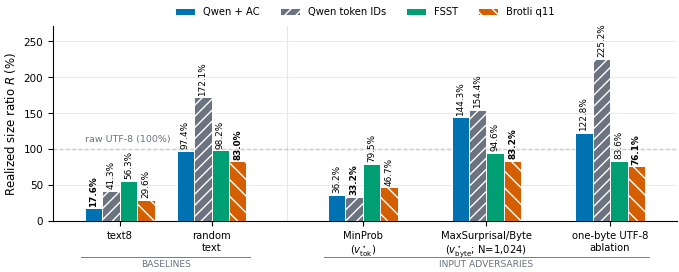

In [6]:
expected = pd.MultiIndex.from_product([
    DATASET_ORDER, ['Qwen + AC', 'Qwen token IDs', 'FSST', 'Brotli q11']
], names=['dataset', 'codec'])
plottable = validate_bar_results(
    bar_audit, DATASET_ORDER, include_preliminary=True
)
observed = pd.MultiIndex.from_frame(plottable[['dataset', 'codec']])
missing_pairs = expected.difference(observed)
payload_only_pairs = pd.MultiIndex.from_frame(
    plottable.loc[
        plottable['status'] == 'payload-only', ['dataset', 'codec']
    ]
)
paper_ready = len(missing_pairs) == 0
readiness = pd.DataFrame({
    'check': [
        f'all {4 * len(DATASET_ORDER)} codec/dataset bars available',
        'all Qwen+AC bars are complete',
        'paper-ready export',
    ],
    'passed': [
        len(missing_pairs) == 0,
        len(payload_only_pairs) == 0,
        paper_ready,
    ],
    'detail': [
        f'{len(missing_pairs)} bars missing',
        payload_only_pairs.tolist(),
        'final PNG emitted' if paper_ready else 'final PNG is gated',
    ],
})
display(readiness)
if len(missing_pairs):
    display(pd.DataFrame(
        missing_pairs.tolist(), columns=['missing_dataset', 'missing_codec']
    ))

fig, ax = plot_compressor_bars(
    bar_audit, PLOT_DATASET_ORDER, include_preliminary=True
)
if paper_ready:
    save_figure(fig, 'end_to_end_compressor_robustness')
else:
    save_figure(fig, 'end_to_end_compressor_robustness_preview')
plt.show()


## Preliminary paper-evaluation sweep

This live view reads the atomically written `results.json` checkpoints from the 10,000-byte printable-ASCII and all one-byte UTF-8 sweeps. It includes only conditions already persisted by the running experiment. Small points are individual seeds; bars and error bars are the mean and sample standard deviation. **Model estimate** is the realized model cross-entropy divided by raw UTF-8 size, while **AC payload** is the finalized arithmetic payload divided by raw UTF-8 size. The dashed line is the uncompressed UTF-8 size.

![Current preliminary sweep](../../../artifacts/figures/neurips/crucial/preliminary_paper_evaluation_sweep.png)


,alphabet,tokens_per_seed,checkpoint
0,Printable ASCII,10000,artifacts/runs/paper-evaluation/printable-asci...
1,All one-byte UTF-8,10000,artifacts/runs/paper-evaluation/ascii-bytes_n1...


,alphabet,condition,seeds,model_mean,model_std,ac_mean,ac_std
0,Printable ASCII,random-token,3,81.34,0.10,96.89,0.09
1,Printable ASCII,min-probability,3,88.42,0.11,103.96,0.10
2,Printable ASCII,surprisal-per-byte,3,88.42,0.11,103.96,0.10
3,Printable ASCII,ordinary-text8,1,11.44,0.00,14.06,0.00
4,Printable ASCII,random-printable-utf8,1,83.83,0.00,94.83,0.00
5,All one-byte UTF-8,random-token,3,91.17,0.11,106.67,0.10
6,All one-byte UTF-8,min-probability,3,104.11,0.02,119.58,0.02
7,All one-byte UTF-8,surprisal-per-byte,3,104.11,0.02,119.58,0.02
8,All one-byte UTF-8,ordinary-text8,1,11.44,0.00,14.06,0.00
9,All one-byte UTF-8,random-printable-utf8,1,83.83,0.00,94.83,0.00


Saved artifacts/figures/neurips/crucial/preliminary_paper_evaluation_sweep.png


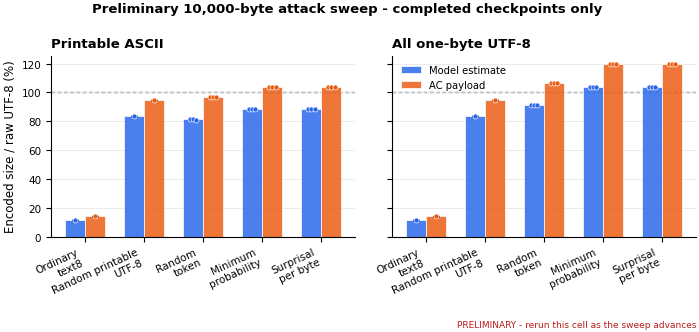

In [7]:
SWEEP_ROOT = ROOT / 'artifacts/runs/paper-evaluation'
SWEEP_SPECS = [
    ('Printable ASCII', SWEEP_ROOT / 'printable-ascii_n10000/results.json'),
    ('All one-byte UTF-8', SWEEP_ROOT / 'ascii-bytes_n10000/results.json'),
]
CONDITION_ORDER = [
    'ordinary-text8', 'random-printable-utf8', 'random-token',
    'min-probability', 'surprisal-per-byte',
]
CONDITION_LABELS = {
    'ordinary-text8': 'Ordinary\ntext8',
    'random-printable-utf8': 'Random printable\nUTF-8',
    'random-token': 'Random\ntoken',
    'min-probability': 'Minimum\nprobability',
    'surprisal-per-byte': 'Surprisal\nper byte',
}

records = []
checkpoint_metadata = []
for alphabet, path in SWEEP_SPECS:
    if not path.is_file():
        continue
    payload = read_json(path)
    metadata = payload['metadata']
    checkpoint_metadata.append({
        'alphabet': alphabet,
        'tokens_per_seed': metadata['total_length'],
        'checkpoint': str(path.relative_to(ROOT)),
    })
    for run in payload['runs']:
        records.append({
            'alphabet': alphabet,
            'condition': run['condition'],
            'seed': run['run_index'],
            'model_estimate_percent': 100 * run['model_entropy_ratio'],
            'ac_payload_percent': 100 * run['arithmetic_payload_ratio'],
        })

if not records:
    raise FileNotFoundError(f'No completed sweep checkpoints under {SWEEP_ROOT}')

sweep = pd.DataFrame(records)
observed_conditions = list(dict.fromkeys(sweep['condition']))
condition_rank = {name: index for index, name in enumerate(CONDITION_ORDER)}
observed_conditions.sort(key=lambda name: (condition_rank.get(name, len(CONDITION_ORDER)), name))
summary = (
    sweep.groupby(['alphabet', 'condition'], sort=False)
    .agg(
        seeds=('seed', 'count'),
        model_mean=('model_estimate_percent', 'mean'),
        model_std=('model_estimate_percent', 'std'),
        ac_mean=('ac_payload_percent', 'mean'),
        ac_std=('ac_payload_percent', 'std'),
    )
    .reset_index()
    .fillna({'model_std': 0.0, 'ac_std': 0.0})
)
display(pd.DataFrame(checkpoint_metadata))
display(summary.round(2))

fig, axes = plt.subplots(1, len(SWEEP_SPECS), figsize=(7.05, 3.35), sharey=True)
axes = np.atleast_1d(axes)
bar_width = 0.34
series = [
    ('model_estimate_percent', 'model_mean', 'model_std', 'Model estimate', '#2563EB'),
    ('ac_payload_percent', 'ac_mean', 'ac_std', 'AC payload', '#EA580C'),
]
for ax, (alphabet, _) in zip(axes, SWEEP_SPECS):
    alphabet_summary = summary[summary['alphabet'] == alphabet].set_index('condition')
    conditions = [name for name in observed_conditions if name in alphabet_summary.index]
    x = np.arange(len(conditions), dtype=float)
    for offset, (raw_column, mean_column, std_column, label, color) in zip((-0.5, 0.5), series):
        centers = x + offset * bar_width
        means = alphabet_summary.loc[conditions, mean_column].to_numpy()
        errors = alphabet_summary.loc[conditions, std_column].to_numpy()
        ax.bar(
            centers, means, bar_width, yerr=errors, capsize=2,
            color=color, alpha=0.82, edgecolor='white', linewidth=0.6,
            label=label, zorder=2,
        )
        for center, condition in zip(centers, conditions):
            values = sweep.loc[
                (sweep['alphabet'] == alphabet) & (sweep['condition'] == condition), raw_column
            ].to_numpy()
            jitter = np.linspace(-0.055, 0.055, len(values)) if len(values) > 1 else np.zeros(1)
            ax.scatter(
                center + jitter, values, s=13, color=color, edgecolor='white',
                linewidth=0.45, zorder=3,
            )
    ax.axhline(100, color='#111827', linestyle=(0, (3, 2)), linewidth=0.9, zorder=1)
    ax.set_title(alphabet, loc='left')
    ax.set_xticks(x, [CONDITION_LABELS.get(name, name) for name in conditions])
    ax.tick_params(axis='x', labelrotation=25)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
    ax.grid(axis='y', color='#E5E7EB', linewidth=0.6, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Encoded size / raw UTF-8 (%)')
axes[-1].legend(frameon=False, loc='upper left')
fig.suptitle(
    'Preliminary 10,000-byte attack sweep - completed checkpoints only',
    fontsize=9.5, fontweight='bold',
)
fig.text(
    0.995, 0.01, 'PRELIMINARY - rerun this cell as the sweep advances',
    ha='right', fontsize=6.5, color='#B91C1C',
)
fig.subplots_adjust(left=0.08, right=0.995, top=0.82, bottom=0.28, wspace=0.12)
save_figure(fig, 'preliminary_paper_evaluation_sweep')
plt.show()


## Required experiments before Figure 2 is paper-ready

The plotted inputs use verified codec measurements, including the complete, decoder-verified 1,024-token MaxSurprisal/Byte QACS stream. The all-one-byte sweep is retained as the controlled tokenizer ablation.
